In [1]:
FF_FILE = "/Users/acxiii2/Book9-FF.CSV"

In [2]:
import os

print(os.getcwd())
print(os.listdir())

/Users/acxiii2
['ele vs space 001.ipynb', '.config', 'Music', 'famafrench Vs assets.ipynb', 'logistic_regression_results.csv', 'Book9-FF.CSV', 'space_oil_3d_surface.html', 'space_oil_correlation_matrix.csv', 'Jts', '.condarc', 'AI vs Space.ipynb', '.DS_Store', '.hwid', '.CFUserTextEncoding', 'cgc_brent_uk_electricity_inflation_data.csv', '.xonshrc', 'brent_energy_tsmc_uk_inflation_returns.csv', 'anaconda_projects', 'Stock Analysis.ipynb', 'Untitled.ipynb', '.zshrc', 'space_oil_cumulative_return.png', 'oil uk cpi .ipynb', 'Pictures', 'FF_assignment2_24_Apr_mine.ipynb', '.zsh_history', 'cgc_regression_results.csv', '.ipython', 'Desktop', 'Library', '.matplotlib', 'oil_analysis_outputs', 'AI_vs_Space_Portfolio_Metrics.csv', 'cgc_sharpe_ratios.csv', 'space_oil_summary_metrics.csv', 'oil vs ele.ipynb', 'Stock Analysis 28may.ipynb', 'space_oil_3d_factor_map.html', 'cgc_correlation_matrix.csv', 'Public', 'FF_assignment2_gpt ver.py', 'space_oil_research_report.html', 'space_oil_correlation_hea


Clean aligned data:
            (BARC, BARC.L)  (SHEL, SHEL.L)  (VOD, VOD.L)  (BLU, BLU.L)  \
2013-02-01        1.993323       -3.168206     -3.805898     90.000000   
2013-03-01       -5.152652       -1.876388     12.715178    -31.578947   
2013-04-01       -1.751646        2.959155      5.144681      0.000000   
2013-05-01       12.025851        0.501844     -2.166144     84.615385   
2013-06-01      -13.103547       -4.663372     -2.135994    -16.666667   

            Mkt-RF   SMB   HML   RF  
2013-02-01    1.29 -0.28  0.11  0.0  
2013-03-01    4.03  0.81 -0.19  0.0  
2013-04-01    1.55 -2.36  0.45  0.0  
2013-05-01    2.80  1.73  2.63  0.0  
2013-06-01   -1.20  1.33  0.03  0.0  

Data shape: (119, 8)

Task 1.1: Other Assets | Dependent variable: ('BARC', 'BARC.L')
MAE:  6.2692
MSE:  66.1895
RMSE: 8.1357
R²:   0.1560
Intercept: -0.0637
Coefficients: [0.26055828 0.3407499  0.03464333]
Kurtosis of y: 1.9660
Skew of y:     -0.4457

Task 1.1: Other Assets | Dependent variable: ('SHEL'

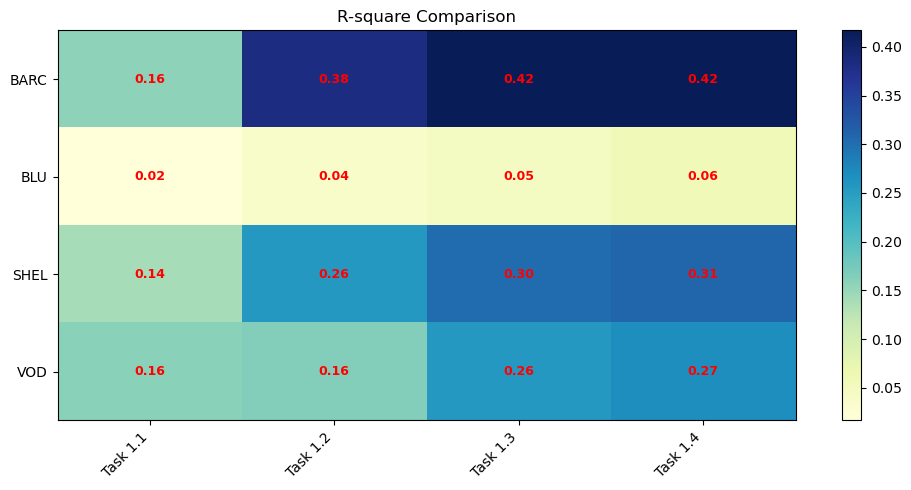

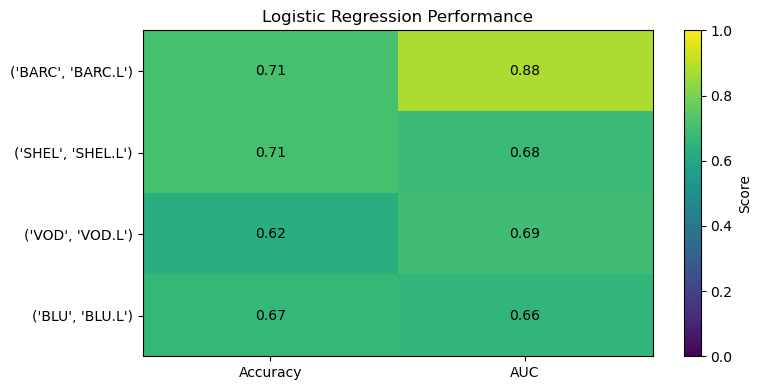


Logistic summary:
             Accuracy       AUC
BARC BARC.L  0.708333  0.875000
SHEL SHEL.L  0.708333  0.680556
VOD  VOD.L   0.625000  0.692308
BLU  BLU.L   0.666667  0.656250
No logistic result found for BARC
No logistic result found for BARC

Saved:
- linear_regression_results.csv
- logistic_regression_results.csv


In [6]:
# ============================================================
# FF FACTORS - Clean Corrected Version
# Purpose:
#   1. Download monthly stock prices from Yahoo Finance
#   2. Convert prices into monthly returns
#   3. Load Fama-French factors
#   4. Run linear regressions:
#        Task 1.1: asset returns explained by other asset returns
#        Task 1.2: asset returns explained by FF factors
#        Task 1.3: asset returns explained by other assets + FF factors
#        Task 1.4: asset returns explained by other assets + FF factors + random control
#   5. Run logistic regressions:
#        Predict whether each asset return beats RF
#   6. Plot R-square and logistic accuracy tables
# ============================================================

# If running in Colab, uncomment this line once:
# !pip install yfinance

import io
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)
from scipy.stats import kurtosis, skew


# ============================================================
# 1. Settings
# ============================================================

START_DATE = "2013-01-01"
END_DATE = "2023-01-01"

TICKERS = {
    "BARC": "BARC.L",   # Barclays
    "SHEL": "SHEL.L",   # Shell
    "VOD":  "VOD.L",    # Vodafone
    "BLU":  "BLU.L"     # Blue Star Capital / original ticker from your code
}

FF_FILE = "Book9-FF.CSV"   # Change this if your file name is different
RANDOM_STATE = 42


# ============================================================
# 2. Helper functions
# ============================================================

def download_monthly_prices(tickers, start, end):
    """
    Download monthly close prices and return a clean price DataFrame.
    auto_adjust=True means Close is adjusted for dividends/splits.
    """
    prices = {}

    for name, ticker in tickers.items():
        data = yf.download(
            ticker,
            start=start,
            end=end,
            interval="1mo",
            auto_adjust=True,
            progress=False
        )

        if data.empty:
            raise ValueError(f"No data downloaded for {name} / {ticker}")

        prices[name] = data["Close"]

    prices = pd.concat(prices, axis=1)
    prices.index = prices.index.to_period("M")
    prices = prices.dropna()

    return prices


def calculate_monthly_returns(prices):
    """
    Convert monthly prices into percentage returns.
    Fama-French data is usually in percentage units, so stock returns are also multiplied by 100.
    """
    returns = prices.pct_change().dropna() * 100
    return returns


def load_fama_french_csv(file_path):
    """
    Load Fama-French CSV and standardise columns.

    Expected columns:
      Mkt-RF, SMB, HML, RF

    The function tries to parse the first date/month column automatically.
    """
    ff = pd.read_csv(file_path)
    ff.columns = ff.columns.astype(str).str.strip()

    required_cols = ["Mkt-RF", "SMB", "HML", "RF"]
    missing = [c for c in required_cols if c not in ff.columns]
    if missing:
        raise ValueError(f"Missing Fama-French columns: {missing}. Current columns: {list(ff.columns)}")

    # Try to find a date/month column
    possible_date_cols = [c for c in ff.columns if c.lower() in ["date", "month", "yyyymm"]]

    if possible_date_cols:
        date_col = possible_date_cols[0]
    else:
        # If no named date column exists, assume the first column is date/month
        date_col = ff.columns[0]

    # Parse YYYYMM style dates, e.g. 201301
    raw_date = ff[date_col].astype(str).str.replace(r"\.0$", "", regex=True).str.strip()

    try:
        ff.index = pd.PeriodIndex(pd.to_datetime(raw_date, format="%Y%m"), freq="M")
    except Exception:
        # Fallback: normal date parsing
        ff.index = pd.to_datetime(raw_date, errors="coerce").dt.to_period("M")

    ff = ff[required_cols].apply(pd.to_numeric, errors="coerce")
    ff = ff.dropna()

    return ff


#def align_returns_and_factors(asset_returns, ff_factors): xx
    """
    Align stock returns and FF factors by monthly period index.
    """
 #   data = asset_returns.join(ff_factors, how="inner")
 #   data = data.dropna()

 #   if data.empty:
 #       raise ValueError("No overlapping dates between stock returns and Fama-French factors.")

 #   return data

def align_returns_and_factors(asset_returns, ff_factors):
    asset_returns = asset_returns.copy()
    ff_factors = ff_factors.copy()

    if isinstance(asset_returns.index, pd.PeriodIndex):
        asset_returns.index = asset_returns.index.to_timestamp()
    else:
        asset_returns.index = pd.to_datetime(asset_returns.index)

    if isinstance(ff_factors.index, pd.PeriodIndex):
        ff_factors.index = ff_factors.index.to_timestamp()
    else:
        ff_factors.index = pd.to_datetime(ff_factors.index)

    asset_returns = asset_returns.loc[:, ~asset_returns.columns.duplicated()]
    ff_factors = ff_factors.loc[:, ~ff_factors.columns.duplicated()]

    # Force remove all FF factor columns from asset_returns
    ff_cols = ["Mkt-RF", "SMB", "HML", "RF"]
    asset_returns = asset_returns.drop(
        columns=[c for c in ff_cols if c in asset_returns.columns],
        errors="ignore"
    )

    # keep only FF factor columns from ff_factors
    ff_factors = ff_factors[ff_cols]

    # use concat instead of merge/join
    data = pd.concat([asset_returns, ff_factors], axis=1, join="inner")
    data = data.dropna()

    if data.empty:
        raise ValueError("No overlapping dates between asset returns and FF factors.")

    return data

#   data = asset_returns.join(ff_factors, how="inner") xx
#    data = pd.merge(asset_returns,ff_factors,left_index=True,right_index=True,how="inner",suffixes=("", "_ff")) xx
#    data = data.dropna()
#    if data.empty:
#        raise ValueError(
#            "No overlapping dates between stock returns and Fama-French factors."   )
#    return data


def print_linear_report(task_name, asset, model, y_true, y_pred):
    """
    Print clean regression statistics.
    """
    print("\n" + "=" * 70)
    print(f"{task_name} | Dependent variable: {asset}")
    print("=" * 70)
    print(f"MAE:  {mean_absolute_error(y_true, y_pred):.4f}")
    print(f"MSE:  {mean_squared_error(y_true, y_pred):.4f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.4f}")
    print(f"R²:   {r2_score(y_true, y_pred):.4f}")
    print(f"Intercept: {model.intercept_:.4f}")
    print("Coefficients:", model.coef_)
    print(f"Kurtosis of y: {kurtosis(y_true):.4f}")
    print(f"Skew of y:     {skew(y_true):.4f}")


#def run_linear_regression_task(data, assets, factor_cols, task_name, feature_builder): xxx
    """
    Run one regression task for all assets.
    feature_builder(asset) must return a list of feature columns.
    """
#    results = []

#    for asset in assets:
#        feature_cols = feature_builder(asset)

#        X = data[feature_cols]
#        y = data[asset]

#        model = LinearRegression()
#        model.fit(X, y)

#        y_pred = model.predict(X)

#        print_linear_report(task_name, asset, model, y, y_pred)

#        row = {
#            "Task": task_name,
#            "Asset": asset,
#            "R2": r2_score(y, y_pred),
#            "MAE": mean_absolute_error(y, y_pred),
#            "RMSE": np.sqrt(mean_squared_error(y, y_pred))
#        }

#        for col, coef in zip(feature_cols, model.coef_):
#            row[f"coef_{col}"] = coef

#        results.append(row)

#    return pd.DataFrame(results)


def run_linear_regression_task(data, assets, factor_cols, task_name, feature_builder):
    results = {}

    for asset in assets:
        feature_cols = feature_builder(asset)

        # only keep columns that actually exist
        feature_cols = [c for c in feature_cols if c in data.columns]

        if len(feature_cols) == 0:
            print(f"Skipping {asset}: no valid feature columns.")
            continue

        reg_data = data[[asset] + feature_cols].copy()

        # force numeric
        reg_data = reg_data.apply(pd.to_numeric, errors="coerce")

        # remove inf and NaN
        reg_data = reg_data.replace([np.inf, -np.inf], np.nan).dropna()

        if reg_data.shape[0] < 10:
            print(f"Skipping {asset}: not enough data.")
            continue

        X = reg_data[feature_cols]
        y = reg_data[asset]

        model = LinearRegression()
        
        X.columns = X.columns.astype(str)
        
        model.fit(X, y)

        y_pred = model.predict(X)

        print_linear_report(task_name, asset, model, y, y_pred)

        results[asset] = {
            "R2": r2_score(y, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y, y_pred)),
            "Intercept": model.intercept_
        }

        for col, coef in zip(feature_cols, model.coef_):
            results[asset][f"Coef_{col}"] = coef

    return results



def run_logistic_regression(data, assets, feature_builder):
    """
    Predict whether each asset return is greater than RF.
    Target:
      1 = asset return > RF
      0 = asset return <= RF
    """
    results = {}

    for asset in assets:
        feature_cols = feature_builder(asset)

        X = data[feature_cols]
        y = (data[asset] > data["RF"]).astype(int)

        # If the target has only one class, logistic regression cannot run.
        if y.nunique() < 2:
            print(f"\nSkipping {asset}: target only has one class.")
            continue

        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=0.2,
            random_state=RANDOM_STATE,
            stratify=y
        )

#        model = LogisticRegression(max_iter=1000)
        
#        model.fit(X_train, y_train)

        X.columns = X.columns.astype(str)

# remove NaN and inf

        X_train = pd.DataFrame(X_train, columns=X.columns)
        X_test = pd.DataFrame(X_test, columns=X.columns) 
        X_train = X_train.replace([np.inf, -np.inf], np.nan)
        X_test = X_test.replace([np.inf, -np.inf], np.nan)

        X_train = X_train.fillna(0)
        X_test = X_test.fillna(0)
        model = LogisticRegression(max_iter=1000)
        model.fit(X_train, y_train)
        
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

        acc = accuracy_score(y_test, y_pred)

        try:
            auc = roc_auc_score(y_test, y_prob)
        except Exception:
            auc = np.nan

        results[asset] = {
            "model": model,
            "features": feature_cols,
            "accuracy": acc,
            "auc": auc,
            "y_test": y_test,
            "y_pred": y_pred,
            "y_prob": y_prob
        }

        print("\n" + "=" * 70)
        print(f"Logistic Regression | Asset beats RF: {asset}")
        print("=" * 70)
        print(f"Accuracy: {acc:.4f}")
        print(f"AUC:      {auc:.4f}")
        print("Features:", feature_cols)
        print("Coefficients:", model.coef_)
        print("Intercept:", model.intercept_)

    return results

#print(linear_results.head())

#print("\nColumns:")
#print(linear_results.columns)

def plot_r2_summary(linear_results):
    """
    Plot R-square comparison.
    Works even if linear_results has MultiIndex.
    """

    df = linear_results.copy()

    # If Asset / Task are in index, reset them into columns
    df = df.reset_index()

    print(df.head())
    print(df.columns)

    # Try to rename index columns if needed
    if "level_0" in df.columns and "Task" not in df.columns:
        df = df.rename(columns={"level_0": "Task"})

    if "level_1" in df.columns and "Asset" not in df.columns:
        df = df.rename(columns={"level_1": "Asset"})

    # If still no Asset column, use first column as Asset
    if "Asset" not in df.columns:
        df = df.rename(columns={df.columns[0]: "Asset"})

    # If still no Task column, create default
    if "Task" not in df.columns:
        df["Task"] = "Linear Regression"

    pivot = df.pivot(index="Asset", columns="Task", values="R2")

    fig, ax = plt.subplots(figsize=(10, 5))
    im = ax.imshow(pivot.values,cmap="YlGnBu", aspect="auto")

    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            ax.text(j,i,f"{pivot.iloc[i,j]:.2f}",ha="center",va="center",color="red", fontsize=9, fontweight="bold")

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=45, ha="right")

    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)

    ax.set_title("R-square Comparison")
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()


def plot_logistic_summary(logistic_results):
    """
    Plot logistic accuracy and AUC.
    """
    if not logistic_results:
        print("No logistic regression results to plot.")
        return

    summary = pd.DataFrame({
        asset: {
            "Accuracy": result["accuracy"],
            "AUC": result["auc"]
        }
        for asset, result in logistic_results.items()
    }).T

    fig, ax = plt.subplots(figsize=(8, 4))
    im = ax.imshow(summary.values, aspect="auto", vmin=0, vmax=1)

    ax.set_xticks(np.arange(len(summary.columns)))
    ax.set_yticks(np.arange(len(summary.index)))
    ax.set_xticklabels(summary.columns)
    ax.set_yticklabels(summary.index)

    for i in range(summary.shape[0]):
        for j in range(summary.shape[1]):
            ax.text(j, i, f"{summary.iloc[i, j]:.2f}", ha="center", va="center")

    ax.set_title("Logistic Regression Performance")
    fig.colorbar(im, ax=ax, label="Score")
    plt.tight_layout()
    plt.show()

    print("\nLogistic summary:")
    print(summary)


def plot_confusion_matrix_for_asset(logistic_results, asset):
    """
    Plot confusion matrix for one asset.
    """
    if asset not in logistic_results:
        print(f"No logistic result found for {asset}")
        return

    result = logistic_results[asset]
    cm = confusion_matrix(result["y_test"], result["y_pred"])

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not beat RF", "Beat RF"])
    disp.plot()
    plt.title(f"Confusion Matrix - {asset}")
    plt.show()


def plot_roc_for_asset(logistic_results, asset):
    """
    Plot ROC curve for one asset.
    """
    if asset not in logistic_results:
        print(f"No logistic result found for {asset}")
        return

    result = logistic_results[asset]
    y_test = result["y_test"]
    y_prob = result["y_prob"]

    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f"AUC = {result['auc']:.2f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {asset}")
    plt.legend()
    plt.tight_layout()
    plt.show()


# ============================================================
# 3. Load data
# ============================================================

prices = download_monthly_prices(TICKERS, START_DATE, END_DATE)
asset_returns = calculate_monthly_returns(prices)
ff_factors = load_fama_french_csv(FF_FILE)

data = align_returns_and_factors(asset_returns, ff_factors)

#assets = list(TICKERS.keys()) xxx
#factor_cols = ["Mkt-RF", "SMB", "HML", "RF"]

assets = [
    col for col in data.columns
    if col not in ["Mkt-RF", "SMB", "HML", "RF"]
]

print("\nClean aligned data:")
print(data.head())
print("\nData shape:", data.shape)

factor_cols = ["Mkt-RF", "SMB", "HML", "RF"]


# ============================================================
# 4. Linear regression tasks
# ============================================================

# Task 1.1: each asset explained by the other three assets
task_11 = run_linear_regression_task(
    data=data,
    assets=assets,
    factor_cols=factor_cols,
    task_name="Task 1.1: Other Assets",
    feature_builder=lambda asset: [a for a in assets if a != asset]
)

# Task 1.2: each asset explained by Fama-French factors
task_12 = run_linear_regression_task(
    data=data,
    assets=assets,
    factor_cols=factor_cols,
    task_name="Task 1.2: FF Factors",
    feature_builder=lambda asset: factor_cols
)

# Task 1.3: each asset explained by other assets + Fama-French factors
task_13 = run_linear_regression_task(
    data=data,
    assets=assets,
    factor_cols=factor_cols,
    task_name="Task 1.3: Other Assets + FF",
    feature_builder=lambda asset: [a for a in assets if a != asset] + factor_cols
)

# Task 1.4: other assets + FF factors + random control variable
# This is included only because your notebook had a random variable task.
# For serious finance interpretation, the random variable should NOT be treated as meaningful.
np.random.seed(RANDOM_STATE)
data["Random_Control"] = np.random.random(len(data))

task_14 = run_linear_regression_task(
    data=data,
    assets=assets,
    factor_cols=factor_cols,
    task_name="Task 1.4: Other Assets + FF + Random",
    feature_builder=lambda asset: [a for a in assets if a != asset] + factor_cols + ["Random_Control"]
)

#linear_results = pd.concat([task_11, task_12, task_13, task_14], ignore_index=True) XX

# VVVV 
#linear_results = pd.concat([pd.DataFrame(task_11).T,pd.DataFrame(task_12).T,pd.DataFrame(task_13).T,pd.DataFrame(task_14).T],
#    keys=[ "Task 1.1 Other Assets","Task 1.2 FF Factors","Task 1.3 Other Assets + FF", "Task 1.4 Other Assets + FF + Random"])


# Or
linear_results = pd.concat(
    [pd.DataFrame(x).T for x in [task_11, task_12, task_13, task_14]],
    keys=["Task 1.1", "Task 1.2", "Task 1.3", "Task 1.4"])


# print("\n" + "=" * 70) XXX
# print("Linear regression summary") XXX
# print("=" * 70)

# print(linear_results[["Task", "Asset", "R2", "MAE", "RMSE"]]) XXX

# better
# print(linear_results)

#Or

print("\nLinear regression summary")
print("-" * 70)


linear_results_display = linear_results.reset_index()
print(linear_results_display)


# ============================================================
# 5. Logistic regression
# ============================================================

# Logistic model: use other assets + FF factors to predict whether asset return beats RF
logistic_results = run_logistic_regression(
    data=data,
    assets=assets,
    feature_builder=lambda asset: [a for a in assets if a != asset] + factor_cols
)


# ============================================================
# 6. Plots
# ============================================================

plot_r2_summary(linear_results)
plot_logistic_summary(logistic_results)

# Optional: choose one asset to inspect more deeply
plot_confusion_matrix_for_asset(logistic_results, "BARC")
plot_roc_for_asset(logistic_results, "BARC")


# ============================================================
# 7. Save outputs
# ============================================================

#linear_results.to_csv("linear_regression_results.csv", index=False) XXX
linear_results_display.to_csv("linear_regression_results.csv", index=False)



logistic_summary = pd.DataFrame({
    asset: {
        "Accuracy": result["accuracy"],
        "AUC": result["auc"]
    }
    for asset, result in logistic_results.items()
}).T

logistic_summary.to_csv("logistic_regression_results.csv")

print("\nSaved:")
print("- linear_regression_results.csv")
print("- logistic_regression_results.csv")


In [ ]:
# ============================================================
# 7. Research Conclusion
# ============================================================

print("\n")
print("=" * 70)
print("RESEARCH CONCLUSION")
print("=" * 70)

# 找出最高 R²
best_asset = linear_results["R2"].astype(float).idxmax()

best_row = linear_results.loc[best_asset]

print(
    f"\nThe strongest explanatory model was observed for "
    f"{best_asset[1]} under {best_asset[0]}."
)

print(
    f"R² = {best_row['R2']:.3f}"
)

print(
    "\nOverall, the analysis suggests that Fama-French factors "
    "and cross-asset relationships provide varying degrees "
    "of explanatory power across the selected assets."
)

print(
    "Higher R² values indicate stronger model fit, while "
    "lower R² values suggest that asset returns are influenced "
    "by additional company-specific or market-specific factors."
)

print(
    "\nInvestors should therefore combine quantitative factor "
    "analysis with fundamental research when evaluating "
    "investment opportunities."
)

In [ ]:
print("\n")
print("=" * 70)
print("ASSET-BY-ASSET CONCLUSION")
print("=" * 70)

for idx, row in linear_results.iterrows():

    asset_name = idx[1]
    task_name = idx[0]

    r2 = float(row["R2"])

    if r2 >= 0.70:
        strength = "very strong"
    elif r2 >= 0.50:
        strength = "moderate"
    else:
        strength = "weak"

    print(
        f"{task_name} | {asset_name}: "
        f"R²={r2:.2f} "
        f"indicates a {strength} explanatory relationship."
    )

In [ ]:
# ============================================================
# Portfolio Style Conclusion
# ============================================================

avg_r2 = linear_results["R2"].astype(float).mean()

print("\n")
print("=" * 70)
print("INVESTMENT RESEARCH SUMMARY")
print("=" * 70)

print(
    f"\nAverage model explanatory power (R²) "
    f"across all regressions was {avg_r2:.2f}."
)

print(
    "\nThe results suggest that factor-based models "
    "can explain part of asset return behaviour, "
    "but substantial variation remains driven by "
    "firm-specific and market-specific conditions."
)

print(
    "This highlights the importance of combining "
    "quantitative modelling with qualitative "
    "fundamental analysis."
)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# ===============================
# Choose asset and regression task
# ===============================

asset = ('SHEL', 'SHEL.L')

                        # ("BARC": "BARC.L"),   # Barclays
                        # ("SHEL": "SHEL.L"),   # Shell
                        # ("VOD":  "VOD.L"),    # Vodafone
                        # ("BLU":  "BLU.L")     # Blue Star Capital / original ticker from your code

factor_cols = ["Mkt-RF", "SMB", "HML", "RF"]

available_assets = [
    c for c in data.columns
    if c not in factor_cols]

print("Available assets:", available_assets)

# asset = available_assets[0]

if asset not in available_assets:
    raise ValueError(f"{asset} not found. Available assets: {available_assets}")

print("Selected asset:", asset)

feature_cols = [a for a in available_assets if a != asset] + factor_cols


# Task option:
# 1. Other assets only
# 2. FF factors only
# 3. Other assets + FF factors

feature_cols = [a for a in assets if a != asset] + factor_cols
# 如果只想 FF factors，用這行：
# feature_cols = factor_cols

# 如果只想 other assets，用這行：
# feature_cols = [a for a in assets if a != asset]

# ===============================
# Clean data
# ===============================

feature_cols = [c for c in feature_cols if c in data.columns]

reg_df = data[[asset] + feature_cols].copy()
reg_df = reg_df.apply(pd.to_numeric, errors="coerce")
reg_df = reg_df.replace([np.inf, -np.inf], np.nan).dropna()

X = reg_df[feature_cols]
y = reg_df[asset]

# fix column-name issue
X.columns = X.columns.astype(str)

# ===============================
# Run regression
# ===============================

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)
residuals = y - y_pred

r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"Asset: {asset}")
print(f"R²: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

# ===============================
# 1. Actual vs Predicted Plot
# ===============================

plt.figure(figsize=(7, 6))

plt.scatter(y, y_pred)

min_val = min(y.min(), y_pred.min())
max_val = max(y.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val])

plt.title(f"{asset}: Actual vs Predicted Returns")
plt.xlabel("Actual Return")
plt.ylabel("Predicted Return")
plt.tight_layout()
plt.show()

# ===============================
# 2. Residual Plot
# ===============================

plt.figure(figsize=(7, 5))

plt.scatter(y_pred, residuals)
plt.axhline(0, linestyle="--")

plt.title(f"{asset}: Residual Plot")
plt.xlabel("Predicted Return")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()

# ===============================
# 3. Residual Histogram
# ===============================

plt.figure(figsize=(7, 5))

plt.hist(residuals, bins=20)

plt.title(f"{asset}: Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()